Mounted at /content/drive
✅ Libraries loaded
✅ Config loaded
   Datasets      : 11
   Train/Test    : 70% / 30%
   kernel        : rbf
   C             : 1.0
   gamma         : scale
   class_weight  : balanced
   probability   : True
  SVM — Kernel Comparison (finding best kernel per dataset)

  AAC        → rbf:0.618  linear:0.571  poly:0.590  sigmoid:0.518
             Best kernel = rbf  (AUC=0.6182)

  DPC        → rbf:0.664  linear:0.541  poly:0.698  sigmoid:0.556
             Best kernel = poly  (AUC=0.6982)

  CTDC       → rbf:0.559  linear:0.537  poly:0.534  sigmoid:0.538
             Best kernel = rbf  (AUC=0.5590)

  CTDT       → rbf:0.589  linear:0.533  poly:0.567  sigmoid:0.464
             Best kernel = rbf  (AUC=0.5889)

  GAAC       → rbf:0.529  linear:0.513  poly:0.533  sigmoid:0.530
             Best kernel = poly  (AUC=0.5328)

  PAAC       → rbf:0.617  linear:0.568  poly:0.601  sigmoid:0.512
             Best kernel = rbf  (AUC=0.6172)

  ProtBERT   → rbf:0.681  line

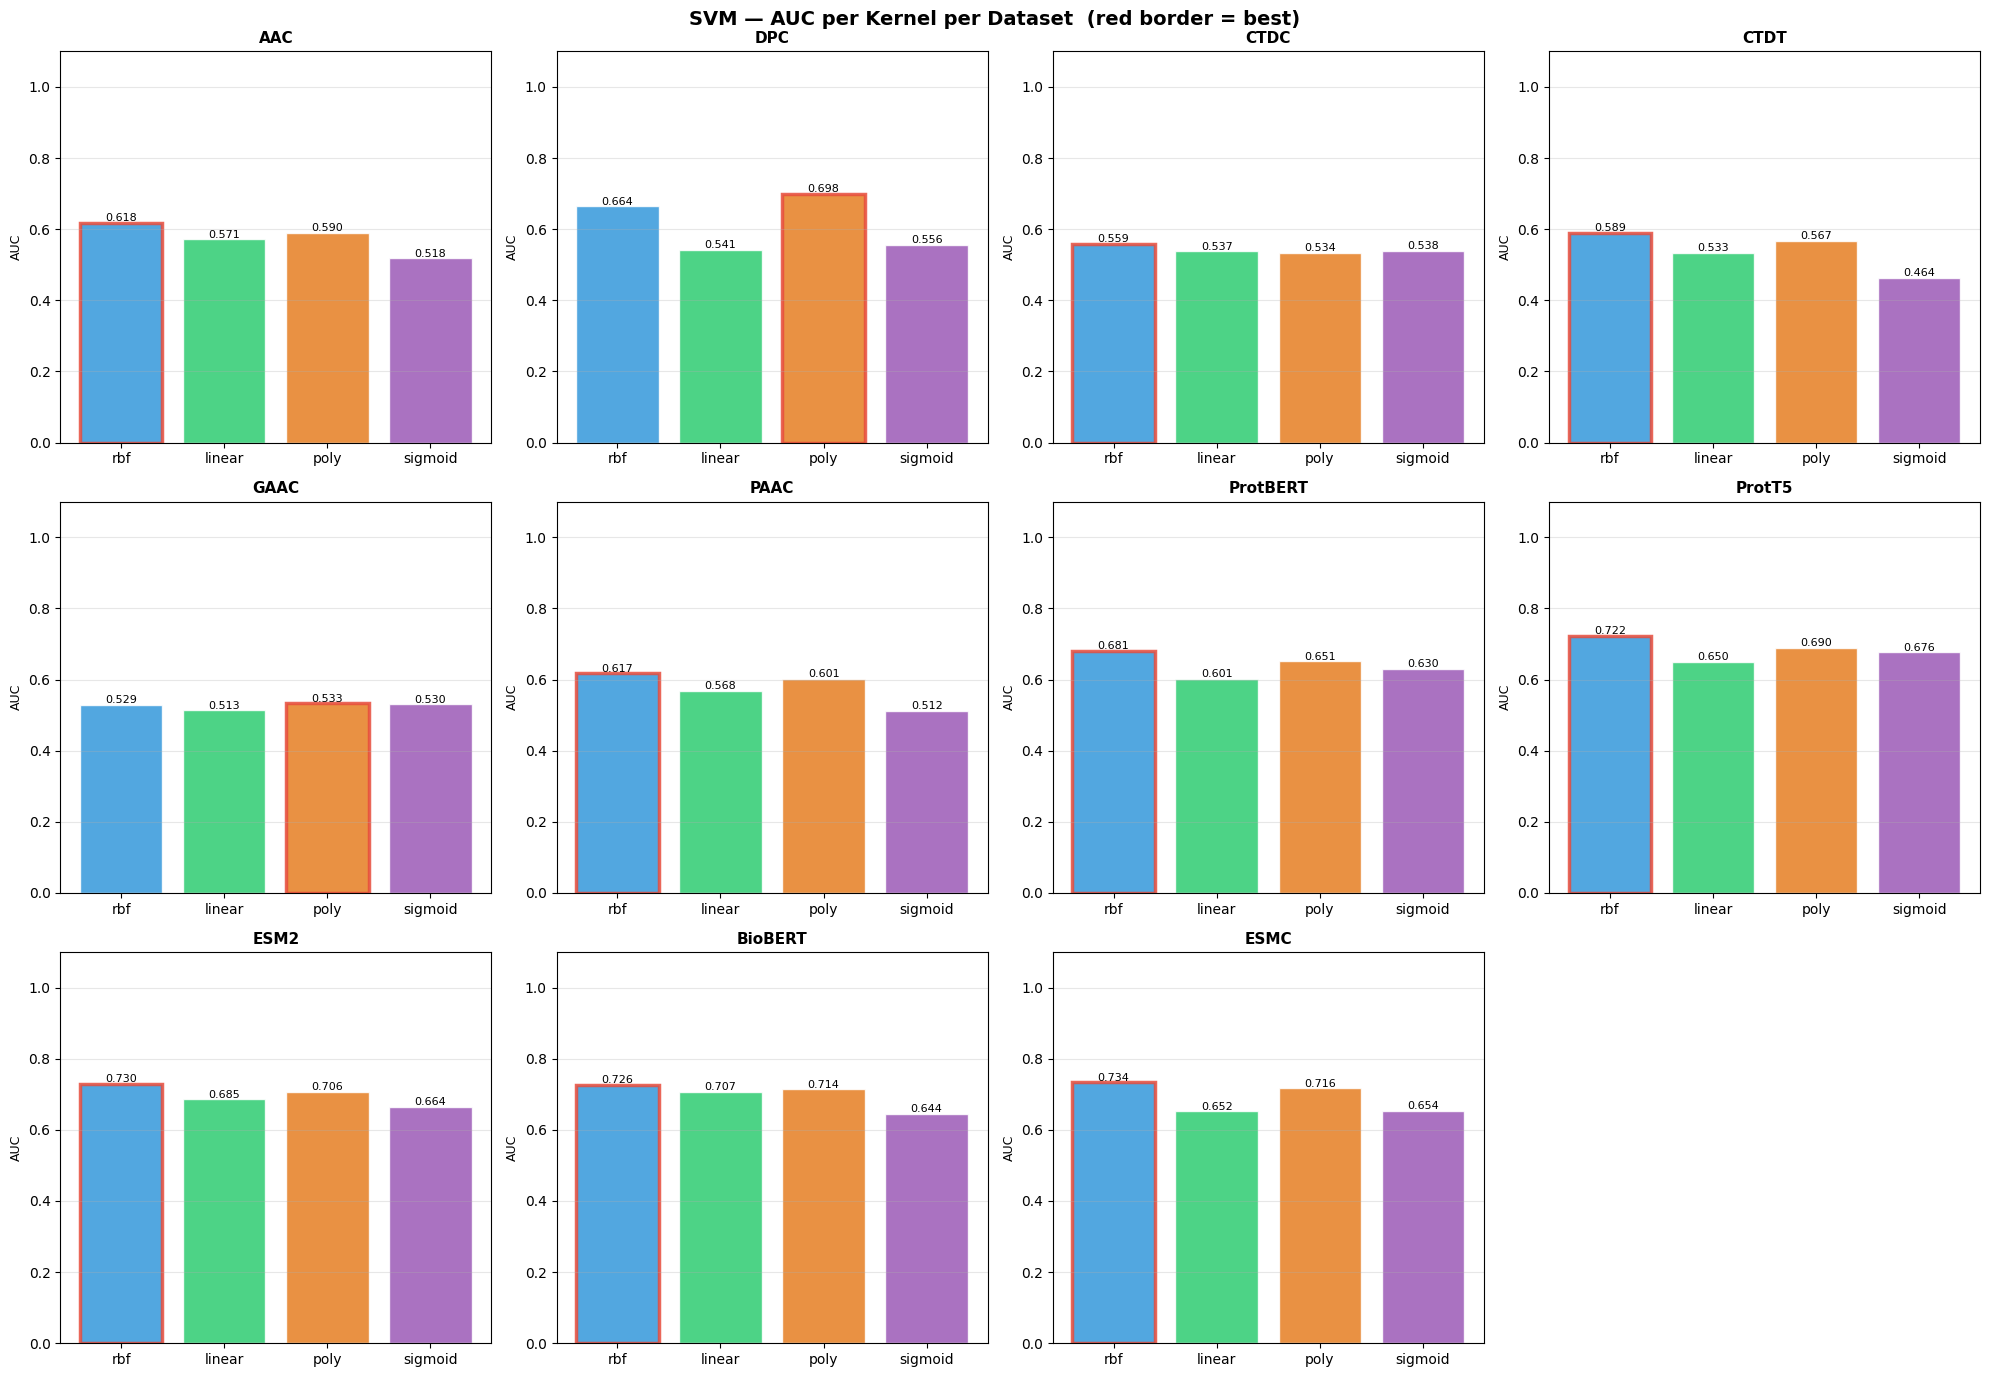

✅ Kernel comparison plot saved
  SVM — Training & Evaluation on 11 Datasets (best kernel each)

────────────────────────────────────────────────────────────
  Dataset : AAC  (AAC_features.csv)
  Shape   : (2190, 21)  |  Features: 20  |  Pos: 876  Neg: 1314
  Train   : 1533 samples  |  Test: 657 samples
  Kernel  : rbf

  ── Results ──────────────────────────────────────
  Accuracy    : 0.5723
  Sensitivity : 0.6122
  Specificity : 0.5457
  F1 Score    : 0.5340
  MCC         : 0.1548
  AUC         : 0.6182
  TP=161  TN=215  FP=179  FN=102
  Probabilities saved → /content/drive/MyDrive/Colab Notebooks/AIP Prediction/results/svm/AAC_SVM_probabilities.csv

────────────────────────────────────────────────────────────
  Dataset : DPC  (DPC_features.csv)
  Shape   : (2190, 401)  |  Features: 400  |  Pos: 876  Neg: 1314
  Train   : 1533 samples  |  Test: 657 samples
  Kernel  : poly

  ── Results ──────────────────────────────────────
  Accuracy    : 0.5662
  Sensitivity : 0.8669
  Specificity

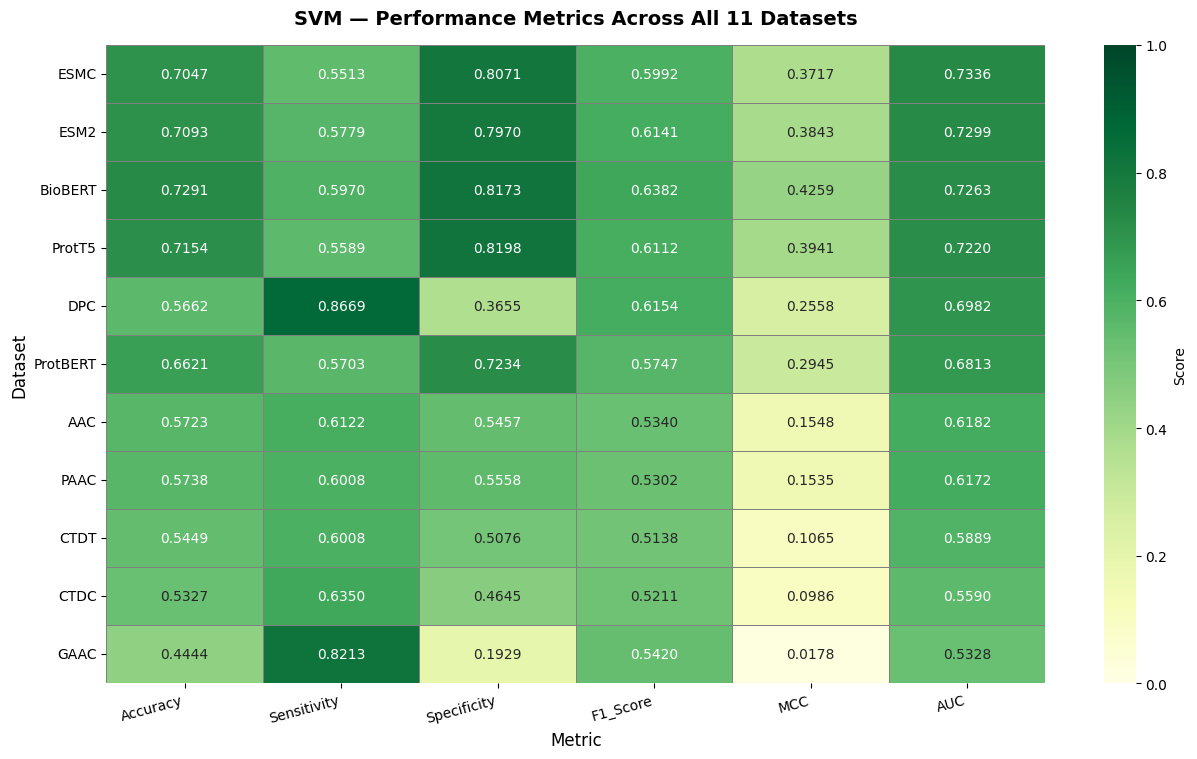

✅ Metrics heatmap saved


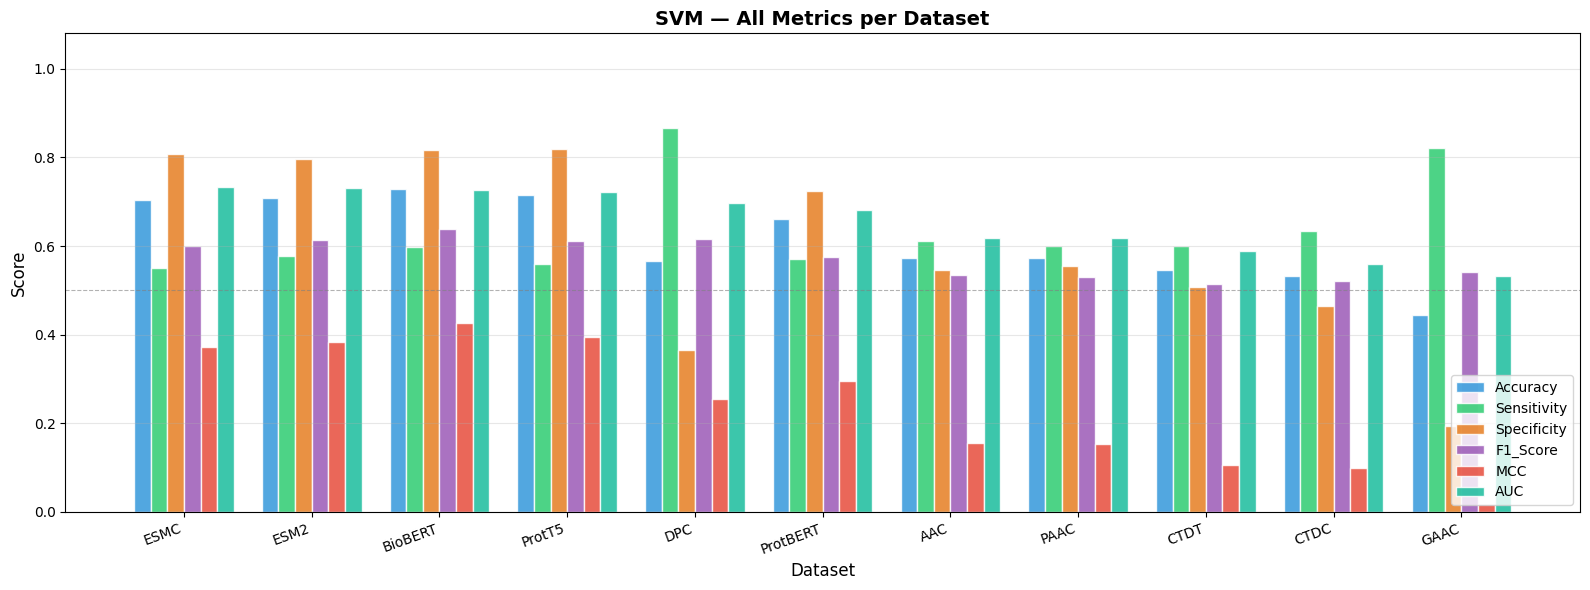

✅ Grouped bar chart saved


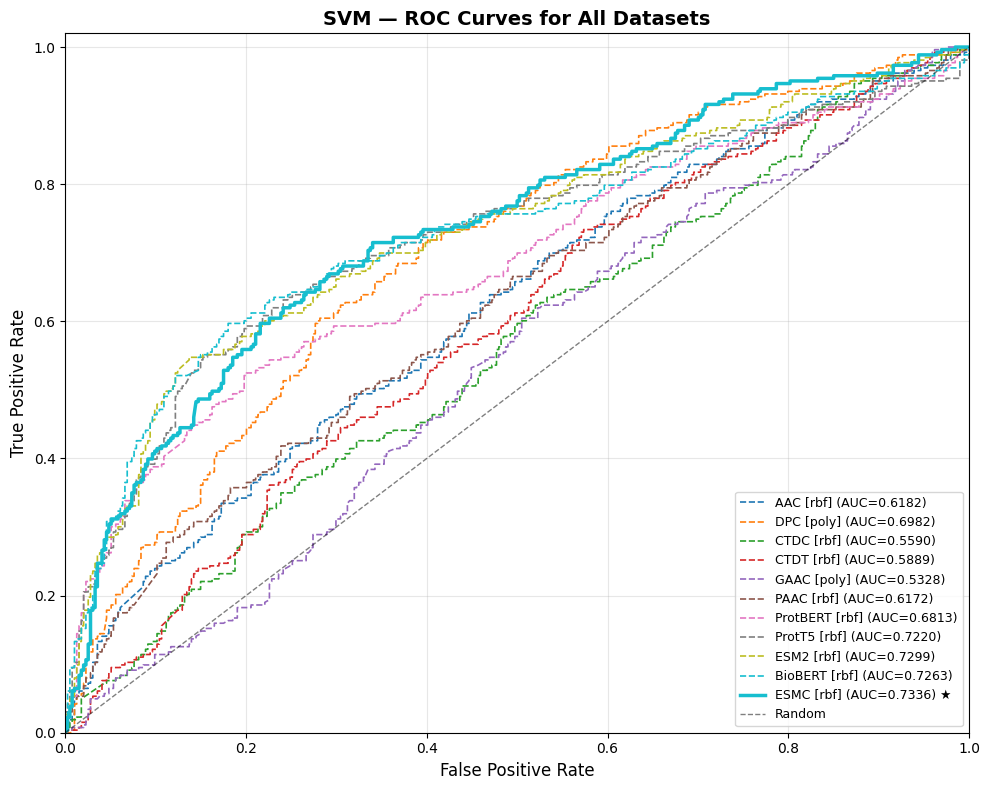

✅ ROC curves saved


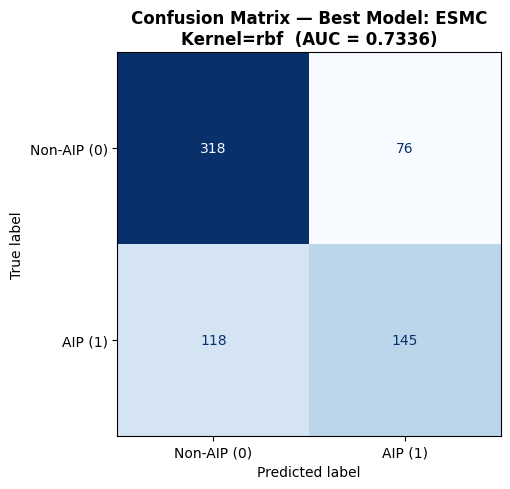

✅ Confusion matrix saved (ESMC)


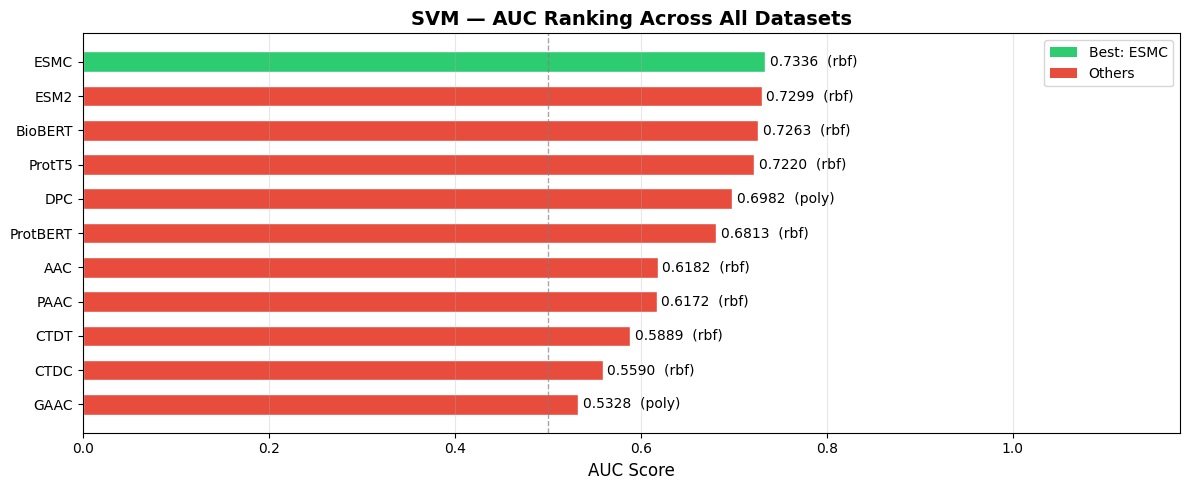

✅ AUC ranking chart saved
  SVM — FINAL SUMMARY

  Results saved to  : /content/drive/MyDrive/Colab Notebooks/AIP Prediction/results/svm
  Figures saved to  : /content/drive/MyDrive/Colab Notebooks/AIP Prediction/results/figures/svm
  Model saved to    : /content/drive/MyDrive/Colab Notebooks/AIP Prediction/models/svm

─────────────────────────────────────────────────────────────────
  Dataset      Kernel        Acc       Sn       Sp       F1      MCC      AUC
─────────────────────────────────────────────────────────────────
  ESMC         rbf        0.7047   0.5513   0.8071   0.5992   0.3717   0.7336 ★
  ESM2         rbf        0.7093   0.5779   0.7970   0.6141   0.3843   0.7299
  BioBERT      rbf        0.7291   0.5970   0.8173   0.6382   0.4259   0.7263
  ProtT5       rbf        0.7154   0.5589   0.8198   0.6112   0.3941   0.7220
  DPC          poly       0.5662   0.8669   0.3655   0.6154   0.2558   0.6982
  ProtBERT     rbf        0.6621   0.5703   0.7234   0.5747   0.2945   0.6813

In [1]:
# ============================================================
#   CELL 1 — Mount Google Drive
# ============================================================
from google.colab import drive
drive.mount('/content/drive')


# ============================================================
#   CELL 2 — Install & Import Libraries
# ============================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings("ignore")

from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, matthews_corrcoef,
    confusion_matrix, roc_auc_score, roc_curve,
    ConfusionMatrixDisplay
)

print("✅ Libraries loaded")


# ============================================================
#   CELL 3 — Configuration
# ============================================================

FEATURE_DIR  = "/content/drive/MyDrive/Colab Notebooks/AIP Prediction/data/features"
RESULTS_DIR  = "/content/drive/MyDrive/Colab Notebooks/AIP Prediction/results/svm"
FIGURES_DIR  = "/content/drive/MyDrive/Colab Notebooks/AIP Prediction/results/figures/svm"
MODELS_DIR   = "/content/drive/MyDrive/Colab Notebooks/AIP Prediction/models/svm"

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(MODELS_DIR,  exist_ok=True)

# ── All 11 feature datasets ──────────────────────────────────
DATASETS = {
    "AAC"     : "AAC_features.csv",
    "DPC"     : "DPC_features.csv",
    "CTDC"    : "CTDC_features.csv",
    "CTDT"    : "CTDT_features.csv",
    "GAAC"    : "GAAC_features.csv",
    "PAAC"    : "PAAC_features.csv",
    "ProtBERT": "ProtBERT_features.csv",
    "ProtT5"  : "ProtT5_features.csv",
    "ESM2"    : "ESM2_features.csv",
    "BioBERT" : "BioBERT_features.csv",
    "ESMC"    : "ESMC_features.csv",
}

# ── SVM hyperparameters ──────────────────────────────────────
#
#  Key SVM parameters:
#    kernel       : the kernel function used to map features
#                   "rbf"    — Radial Basis Function ✅ best for most tasks
#                   "linear" — good for high-dim PLM features (768–1280 dims)
#                   "poly"   — polynomial, rarely used for peptides
#                   "sigmoid"— rarely used
#    C            : regularisation parameter
#                   high C  = low bias, high variance (overfit risk)
#                   low  C  = high bias, low variance (underfit risk)
#                   try: 0.1, 1, 10, 100
#    gamma        : kernel coefficient for "rbf"
#                   "scale" = 1/(n_features × X.var())  ✅ default
#                   "auto"  = 1/n_features
#    class_weight : "balanced" adjusts for 1:1.5 AIP/non-AIP imbalance
#    probability  : True  — enables predict_proba() for AUC/ROC
#                   adds ~3× training time via cross-validation
#    cache_size   : MB of RAM for kernel cache — increase if RAM allows
#
#  ⚠️  SVM is the most sensitive to feature scaling of all classifiers.
#      StandardScaler is mandatory — without it SVM will perform poorly.
#  ⚠️  SVM can be slow on PLM datasets (768–1280 dims, N>1000).
#      Use kernel="linear" for faster training on high-dim features.
#
SVM_PARAMS = {
    "kernel"      : "rbf",
    "C"           : 1.0,
    "gamma"       : "scale",
    "class_weight": "balanced",
    "probability" : True,          # required for predict_proba / AUC
    "cache_size"  : 500,           # MB — increase to 1000 if RAM allows
    "random_state": 42,
}

TEST_SIZE    = 0.30
RANDOM_STATE = 42

print(f"✅ Config loaded")
print(f"   Datasets      : {len(DATASETS)}")
print(f"   Train/Test    : {int((1-TEST_SIZE)*100)}% / {int(TEST_SIZE*100)}%")
print(f"   kernel        : {SVM_PARAMS['kernel']}")
print(f"   C             : {SVM_PARAMS['C']}")
print(f"   gamma         : {SVM_PARAMS['gamma']}")
print(f"   class_weight  : {SVM_PARAMS['class_weight']}")
print(f"   probability   : {SVM_PARAMS['probability']}")


# ============================================================
#   CELL 4 — Metric Helper Functions
# ============================================================

def compute_metrics(y_true, y_pred, y_prob):
    """
    Compute all 6 performance metrics.

    Metrics:
      Accuracy    = (TP + TN) / (TP + TN + FP + FN)
      Sensitivity = TP / (TP + FN)   [Recall for positive class]
      Specificity = TN / (TN + FP)   [Recall for negative class]
      F1 Score    = 2 × (Precision × Recall) / (Precision + Recall)
      MCC         = Matthews Correlation Coefficient
      AUC         = Area Under ROC Curve
    """
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    accuracy    = accuracy_score(y_true, y_pred)
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    f1          = f1_score(y_true, y_pred, zero_division=0)
    mcc         = matthews_corrcoef(y_true, y_pred)
    auc         = roc_auc_score(y_true, y_prob)

    return {
        "Accuracy"   : round(accuracy,    4),
        "Sensitivity": round(sensitivity, 4),
        "Specificity": round(specificity, 4),
        "F1_Score"   : round(f1,          4),
        "MCC"        : round(mcc,         4),
        "AUC"        : round(auc,         4),
        "TP": int(tp), "TN": int(tn),
        "FP": int(fp), "FN": int(fn),
    }


def load_dataset(csv_path):
    """
    Load a feature CSV, auto-detect feature columns and label.
    Expects: seq_id column, feature columns, label column (last).
    """
    df = pd.read_csv(csv_path)

    drop_cols = [c for c in ["seq_id", "sequence", "length"]
                 if c in df.columns]
    df = df.drop(columns=drop_cols)

    X = df.iloc[:, :-1].values
    y = df.iloc[:, -1].values.astype(int)

    return X, y, df.columns[-1], df.shape


# ============================================================
#   CELL 5 — Kernel Comparison
#            Sweep over kernels for each dataset to pick best
#            Tests: "rbf", "linear", "poly", "sigmoid"
# ============================================================

print("=" * 65)
print("  SVM — Kernel Comparison (finding best kernel per dataset)")
print("=" * 65)

KERNELS           = ["rbf", "linear", "poly", "sigmoid"]
best_kernel_per_ds = {}    # best kernel per dataset

for ds_name, csv_file in DATASETS.items():

    csv_path = os.path.join(FEATURE_DIR, csv_file)
    if not os.path.exists(csv_path):
        continue

    X, y, _, _ = load_dataset(csv_path)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE,
        random_state=RANDOM_STATE, stratify=y
    )

    scaler  = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)

    kernel_aucs = {}
    for kernel in KERNELS:
        svm = SVC(
            kernel       = kernel,
            C            = SVM_PARAMS["C"],
            gamma        = SVM_PARAMS["gamma"],
            class_weight = SVM_PARAMS["class_weight"],
            probability  = True,
            cache_size   = SVM_PARAMS["cache_size"],
            random_state = SVM_PARAMS["random_state"],
        )
        svm.fit(X_train, y_train)
        y_prob_k           = svm.predict_proba(X_test)[:, 1]
        kernel_aucs[kernel] = round(roc_auc_score(y_test, y_prob_k), 4)

    best_kernel               = max(kernel_aucs, key=kernel_aucs.get)
    best_kernel_per_ds[ds_name] = best_kernel

    k_str = "  ".join([f"{k}:{v:.3f}" for k, v in kernel_aucs.items()])
    print(f"\n  {ds_name:<10} → {k_str}")
    print(f"             Best kernel = {best_kernel}  "
          f"(AUC={kernel_aucs[best_kernel]:.4f})")

print(f"\n✅ Kernel comparison complete")
print(f"   Best kernel per dataset: {best_kernel_per_ds}")


# ============================================================
#   CELL 6 — Kernel Comparison Plot
# ============================================================

fig, axes = plt.subplots(3, 4, figsize=(20, 14), sharey=False)
axes = axes.flatten()

kernel_colors = {
    "rbf"    : "#3498db",
    "linear" : "#2ecc71",
    "poly"   : "#e67e22",
    "sigmoid": "#9b59b6",
}

for idx, (ds_name, csv_file) in enumerate(DATASETS.items()):

    csv_path = os.path.join(FEATURE_DIR, csv_file)
    if not os.path.exists(csv_path):
        axes[idx].set_visible(False)
        continue

    ax = axes[idx]
    X, y, _, _ = load_dataset(csv_path)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE,
        random_state=RANDOM_STATE, stratify=y
    )
    scaler  = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)

    k_aucs = []
    for kernel in KERNELS:
        svm = SVC(
            kernel=kernel, C=SVM_PARAMS["C"],
            gamma=SVM_PARAMS["gamma"],
            class_weight=SVM_PARAMS["class_weight"],
            probability=True, cache_size=SVM_PARAMS["cache_size"],
            random_state=SVM_PARAMS["random_state"],
        )
        svm.fit(X_train, y_train)
        y_prob_k = svm.predict_proba(X_test)[:, 1]
        k_aucs.append(roc_auc_score(y_test, y_prob_k))

    bars = ax.bar(
        KERNELS, k_aucs,
        color=[kernel_colors[k] for k in KERNELS],
        edgecolor="white", alpha=0.85
    )

    # Highlight best kernel
    best_k   = best_kernel_per_ds.get(ds_name, "rbf")
    best_idx = KERNELS.index(best_k)
    bars[best_idx].set_edgecolor("#e74c3c")
    bars[best_idx].set_linewidth(2.5)

    for bar, val in zip(bars, k_aucs):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f"{val:.3f}", ha="center", fontsize=8)

    ax.set_title(ds_name, fontsize=11, fontweight="bold")
    ax.set_ylabel("AUC", fontsize=9)
    ax.set_ylim(0, 1.1)
    ax.grid(axis="y", alpha=0.3)

for idx in range(len(DATASETS), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle("SVM — AUC per Kernel per Dataset  (red border = best)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "SVM_kernel_comparison.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Kernel comparison plot saved")


# ============================================================
#   CELL 7 — Main Training Loop (using best kernel per dataset)
# ============================================================

all_results  = []
best_model   = None
best_scaler  = None
best_name    = ""
best_auc     = -1.0
all_probs    = {}

print("=" * 65)
print("  SVM — Training & Evaluation on 11 Datasets (best kernel each)")
print("=" * 65)

for ds_name, csv_file in DATASETS.items():

    csv_path = os.path.join(FEATURE_DIR, csv_file)

    if not os.path.exists(csv_path):
        print(f"\n⏭  [{ds_name}] File not found — skipping: {csv_file}")
        continue

    print(f"\n{'─'*60}")
    print(f"  Dataset : {ds_name}  ({csv_file})")

    # ── Load & split ─────────────────────────────────────────
    X, y, label_col, shape = load_dataset(csv_path)
    print(f"  Shape   : {shape}  |  Features: {X.shape[1]}  |  "
          f"Pos: {y.sum()}  Neg: {(y==0).sum()}")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size    = TEST_SIZE,
        random_state = RANDOM_STATE,
        stratify     = y
    )

    print(f"  Train   : {len(X_train)} samples  |  "
          f"Test: {len(X_test)} samples")

    # ── Scale features ───────────────────────────────────────
    # ⚠️ Critical for SVM — without scaling SVM performs poorly
    scaler  = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)

    # ── Use best kernel found in comparison ──────────────────
    kernel_used = best_kernel_per_ds.get(ds_name, SVM_PARAMS["kernel"])
    print(f"  Kernel  : {kernel_used}")

    # ── Train SVM ────────────────────────────────────────────
    clf = SVC(
        kernel       = kernel_used,
        C            = SVM_PARAMS["C"],
        gamma        = SVM_PARAMS["gamma"],
        class_weight = SVM_PARAMS["class_weight"],
        probability  = SVM_PARAMS["probability"],
        cache_size   = SVM_PARAMS["cache_size"],
        random_state = SVM_PARAMS["random_state"],
    )
    clf.fit(X_train, y_train)

    # ── Predict ──────────────────────────────────────────────
    y_pred = clf.predict(X_test)
    y_prob = clf.predict_proba(X_test)[:, 1]

    # ── Metrics ──────────────────────────────────────────────
    metrics = compute_metrics(y_test, y_pred, y_prob)
    metrics["Dataset"]     = ds_name
    metrics["Features"]    = X.shape[1]
    metrics["Kernel_used"] = kernel_used
    metrics["Train_N"]     = len(X_train)
    metrics["Test_N"]      = len(X_test)
    all_results.append(metrics)

    print(f"\n  ── Results ──────────────────────────────────────")
    print(f"  Accuracy    : {metrics['Accuracy']:.4f}")
    print(f"  Sensitivity : {metrics['Sensitivity']:.4f}")
    print(f"  Specificity : {metrics['Specificity']:.4f}")
    print(f"  F1 Score    : {metrics['F1_Score']:.4f}")
    print(f"  MCC         : {metrics['MCC']:.4f}")
    print(f"  AUC         : {metrics['AUC']:.4f}")
    print(f"  TP={metrics['TP']}  TN={metrics['TN']}  "
          f"FP={metrics['FP']}  FN={metrics['FN']}")

    # ── Save probabilities ───────────────────────────────────
    df_probs = pd.DataFrame({
        "y_true"       : y_test,
        "y_pred"       : y_pred,
        "prob_positive": y_prob,
        "prob_negative": 1 - y_prob,
    })
    prob_path = os.path.join(RESULTS_DIR, f"{ds_name}_SVM_probabilities.csv")
    df_probs.to_csv(prob_path, index=False)

    all_probs[ds_name] = {
        "y_test" : y_test,
        "y_pred" : y_pred,
        "y_prob" : y_prob,
        "clf"    : clf,
        "scaler" : scaler,
        "kernel" : kernel_used,
    }

    # ── Track best model ─────────────────────────────────────
    if metrics["AUC"] > best_auc:
        best_auc    = metrics["AUC"]
        best_name   = ds_name
        best_model  = clf
        best_scaler = scaler

    print(f"  Probabilities saved → {prob_path}")

print(f"\n{'='*65}")
print(f"  ✅ Training complete for {len(all_results)} datasets")
print(f"  🏆 Best model: {best_name}  (AUC = {best_auc:.4f})")
print(f"{'='*65}")


# ============================================================
#   CELL 8 — Results Summary Table
# ============================================================

metric_cols = ["Dataset", "Kernel_used", "Accuracy", "Sensitivity",
               "Specificity", "F1_Score", "MCC", "AUC", "Features"]

df_results = pd.DataFrame(all_results)[metric_cols].sort_values(
    "AUC", ascending=False
).reset_index(drop=True)

df_results.index += 1

print("\n── SVM Performance Summary (sorted by AUC) ──")
print(df_results.to_string())

summary_path = os.path.join(RESULTS_DIR, "SVM_all_results_summary.csv")
df_results.to_csv(summary_path, index=True, index_label="Rank")
print(f"\n✅ Summary saved → {summary_path}")


# ============================================================
#   CELL 9 — Save Best Model
# ============================================================

best_model_path  = os.path.join(MODELS_DIR, f"SVM_best_model_{best_name}.joblib")
best_scaler_path = os.path.join(MODELS_DIR, f"SVM_best_scaler_{best_name}.joblib")

joblib.dump(best_model,  best_model_path)
joblib.dump(best_scaler, best_scaler_path)

print(f"✅ Best model saved")
print(f"   Dataset : {best_name}")
print(f"   Kernel  : {best_kernel_per_ds.get(best_name)}")
print(f"   AUC     : {best_auc:.4f}")
print(f"   Model   : {best_model_path}")
print(f"   Scaler  : {best_scaler_path}")


# ============================================================
#   CELL 10 — Visualization 1: Metrics Heatmap (All Datasets)
# ============================================================

heat_cols = ["Accuracy", "Sensitivity", "Specificity", "F1_Score", "MCC", "AUC"]
heat_data = df_results.set_index("Dataset")[heat_cols]

fig, ax = plt.subplots(figsize=(13, max(5, len(heat_data) * 0.7)))

sns.heatmap(
    heat_data,
    annot     = True,
    fmt       = ".4f",
    cmap      = "YlGn",
    linewidths= 0.5,
    linecolor = "grey",
    vmin      = 0,
    vmax      = 1,
    ax        = ax,
    cbar_kws  = {"label": "Score"}
)

ax.set_title("SVM — Performance Metrics Across All 11 Datasets",
             fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Metric", fontsize=12)
ax.set_ylabel("Dataset", fontsize=12)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)
ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha="right", fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "SVM_metrics_heatmap.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Metrics heatmap saved")


# ============================================================
#   CELL 11 — Visualization 2: Grouped Bar Chart (All Metrics)
# ============================================================

fig, ax = plt.subplots(figsize=(16, 6))

x      = np.arange(len(df_results))
width  = 0.13
colors = ["#3498db", "#2ecc71", "#e67e22", "#9b59b6", "#e74c3c", "#1abc9c"]

for i, (col, color) in enumerate(zip(heat_cols, colors)):
    offset = (i - len(heat_cols) / 2 + 0.5) * width
    ax.bar(x + offset, df_results[col].values,
           width, label=col, color=color,
           alpha=0.85, edgecolor="white")

ax.set_xlabel("Dataset", fontsize=12)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("SVM — All Metrics per Dataset",
             fontsize=14, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(df_results["Dataset"], rotation=20, ha="right", fontsize=10)
ax.set_ylim(0, 1.08)
ax.legend(fontsize=10, loc="lower right")
ax.grid(axis="y", alpha=0.3)
ax.axhline(0.5, color="grey", linestyle="--", linewidth=0.8, alpha=0.6)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "SVM_grouped_bar_chart.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Grouped bar chart saved")


# ============================================================
#   CELL 12 — Visualization 3: ROC Curves (All Datasets)
# ============================================================

fig, ax = plt.subplots(figsize=(10, 8))

cmap   = plt.cm.get_cmap("tab10", len(all_probs))
colors = [cmap(i) for i in range(len(all_probs))]

for (ds_name, data), color in zip(all_probs.items(), colors):
    fpr, tpr, _ = roc_curve(data["y_test"], data["y_prob"])
    auc_val     = roc_auc_score(data["y_test"], data["y_prob"])
    lw          = 2.5 if ds_name == best_name else 1.2
    ls          = "-"  if ds_name == best_name else "--"
    ax.plot(fpr, tpr, color=color, linewidth=lw, linestyle=ls,
            label=f"{ds_name} [{data['kernel']}] (AUC={auc_val:.4f})"
                  + (" ★" if ds_name == best_name else ""))

ax.plot([0, 1], [0, 1], "k--", linewidth=1, alpha=0.5, label="Random")
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("SVM — ROC Curves for All Datasets",
             fontsize=14, fontweight="bold")
ax.legend(fontsize=9, loc="lower right")
ax.grid(alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "SVM_ROC_curves.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ ROC curves saved")


# ============================================================
#   CELL 13 — Visualization 4: Confusion Matrix (Best Model)
# ============================================================

best_data = all_probs[best_name]
cm        = confusion_matrix(best_data["y_test"], best_data["y_pred"])

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix = cm,
    display_labels   = ["Non-AIP (0)", "AIP (1)"]
)
disp.plot(cmap="Blues", ax=ax, colorbar=False)

ax.set_title(f"Confusion Matrix — Best Model: {best_name}\n"
             f"Kernel={best_kernel_per_ds.get(best_name)}  "
             f"(AUC = {best_auc:.4f})",
             fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR,
                         f"SVM_confusion_matrix_{best_name}.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Confusion matrix saved ({best_name})")


# ============================================================
#   CELL 14 — Visualization 5: AUC Ranking Bar Chart
# ============================================================

fig, ax = plt.subplots(figsize=(12, 5))

sorted_df  = df_results.sort_values("AUC", ascending=True)
bar_colors = ["#e74c3c" if n != best_name else "#2ecc71"
              for n in sorted_df["Dataset"]]

bars = ax.barh(sorted_df["Dataset"], sorted_df["AUC"],
               color=bar_colors, edgecolor="white", height=0.6)

for bar, val, kernel in zip(bars, sorted_df["AUC"],
                             sorted_df["Kernel_used"]):
    ax.text(bar.get_width() + 0.005,
            bar.get_y() + bar.get_height()/2,
            f"{val:.4f}  ({kernel})", va="center", fontsize=10)

ax.axvline(0.5, color="grey", linestyle="--", linewidth=1, alpha=0.7)
ax.set_xlabel("AUC Score", fontsize=12)
ax.set_title("SVM — AUC Ranking Across All Datasets",
             fontsize=14, fontweight="bold")
ax.set_xlim(0, 1.18)
ax.grid(axis="x", alpha=0.3)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor="#2ecc71", label=f"Best: {best_name}"),
                   Patch(facecolor="#e74c3c", label="Others")]
ax.legend(handles=legend_elements, fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "SVM_AUC_ranking.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ AUC ranking chart saved")


# ============================================================
#   CELL 15 — Final Summary
# ============================================================

best_row = df_results[df_results["Dataset"] == best_name].iloc[0]

print("=" * 65)
print("  SVM — FINAL SUMMARY")
print("=" * 65)
print(f"\n  Results saved to  : {RESULTS_DIR}")
print(f"  Figures saved to  : {FIGURES_DIR}")
print(f"  Model saved to    : {MODELS_DIR}")
print(f"\n{'─'*65}")
print(f"  {'Dataset':<12} {'Kernel':<8} {'Acc':>8} {'Sn':>8} {'Sp':>8} "
      f"{'F1':>8} {'MCC':>8} {'AUC':>8}")
print(f"{'─'*65}")
for _, row in df_results.iterrows():
    marker = " ★" if row["Dataset"] == best_name else ""
    print(f"  {row['Dataset']:<12} {row['Kernel_used']:<8} "
          f"{row['Accuracy']:>8.4f} "
          f"{row['Sensitivity']:>8.4f} {row['Specificity']:>8.4f} "
          f"{row['F1_Score']:>8.4f} {row['MCC']:>8.4f} "
          f"{row['AUC']:>8.4f}{marker}")
print(f"{'─'*65}")
print(f"\n  🏆 Best Dataset : {best_name}")
print(f"     Kernel      : {best_kernel_per_ds.get(best_name)}")
print(f"     Accuracy    : {best_row['Accuracy']:.4f}")
print(f"     Sensitivity : {best_row['Sensitivity']:.4f}")
print(f"     Specificity : {best_row['Specificity']:.4f}")
print(f"     F1 Score    : {best_row['F1_Score']:.4f}")
print(f"     MCC         : {best_row['MCC']:.4f}")
print(f"     AUC         : {best_row['AUC']:.4f}")
print(f"\n  SVM notes:")
print(f"     ✅ Maximises margin between classes")
print(f"     ✅ Best kernel selected per dataset automatically")
print(f"     ✅ class_weight='balanced' handles 1:1.5 imbalance")
print(f"     ⚠️  StandardScaler is mandatory for SVM")
print(f"     ⚠️  probability=True adds ~3× training time (Platt scaling)")
print(f"     ⚠️  Slow on PLM datasets — use kernel='linear' if needed")
print("=" * 65)